In [11]:
import pandas as pd
import numpy as np

In [12]:
students=pd.read_csv("StressLevelDataset.csv")

In [13]:
students.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [14]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [15]:
students.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [16]:
for col in students.columns:
    print(f"{col}: {students[col].min()} to {students[col].max()}")

anxiety_level: 0 to 21
self_esteem: 0 to 30
mental_health_history: 0 to 1
depression: 0 to 27
headache: 0 to 5
blood_pressure: 1 to 3
sleep_quality: 0 to 5
breathing_problem: 0 to 5
noise_level: 0 to 5
living_conditions: 0 to 5
safety: 0 to 5
basic_needs: 0 to 5
academic_performance: 0 to 5
study_load: 0 to 5
teacher_student_relationship: 0 to 5
future_career_concerns: 0 to 5
social_support: 0 to 3
peer_pressure: 0 to 5
extracurricular_activities: 0 to 5
bullying: 0 to 5
stress_level: 0 to 2


In [17]:
X=students.drop(columns=['stress_level'])
Y=students['stress_level']

In [18]:
X.shape, Y.shape

((1100, 20), (1100,))

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,target_names=['Low','Medium','High']))

Accuracy Score: 0.8681818181818182

Classification Report:
               precision    recall  f1-score   support

         Low       0.88      0.86      0.87        76
      Medium       0.85      0.86      0.86        73
        High       0.88      0.89      0.88        71

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [23]:
new_data = {
    "anxiety_level": 0,
    "self_esteem": 2,
    "mental_health_history": 0,
    "depression": 7,
    "headache": 0,
    "blood_pressure": 3,
    "sleep_quality": 0,
    "breathing_problem": 4,
    "noise_level": 5,
    "living_conditions":1,
    "safety": 0,
    "basic_needs": 5,
    "academic_performance": 2,
    "study_load": 5,
    "teacher_student_relationship": 5,
    "future_career_concerns": 5,
    "social_support": 3,
    "peer_pressure": 0,
    "extracurricular_activities": 5,
    "bullying": 0
}


new_df_toPredict = pd.DataFrame([new_data])

# Use your trained RandomForestClassifier
prediction = model.predict(new_df_toPredict)

print("Predicted Stress Level:", prediction[0])

Predicted Stress Level: 2


C:\Users\Rida\AppData\Local\Temp\ipykernel_21436\3699234507.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


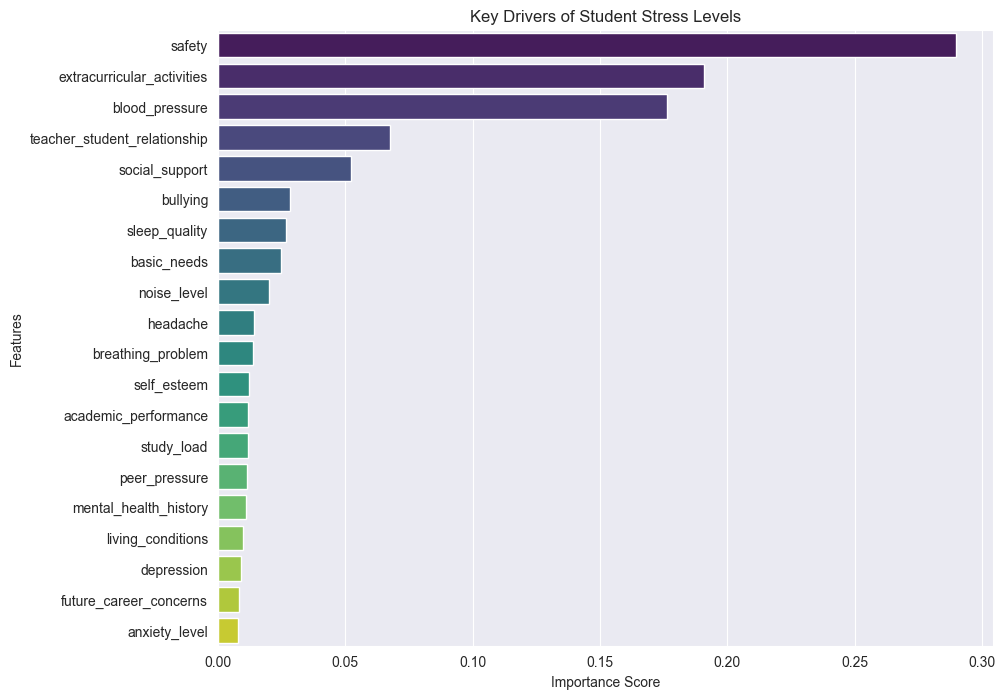

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Drivers of Student Stress Levels')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

<Figure size 800x600 with 0 Axes>

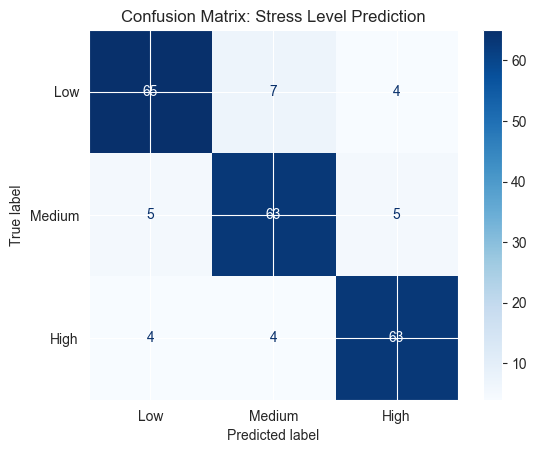

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Stress Level Prediction')
plt.show()

In [26]:
!pip install huggingface_hub


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from huggingface_hub import InferenceClient

# Replace with your actual token
HF_TOKEN = "HF_TOKEN=your_token_here"

# We'll use a fast, smart model like Llama-3-8B
client = InferenceClient(model="meta-llama/Meta-Llama-3-8B-Instruct", token=HF_TOKEN)

def get_ai_counselor_advice(prediction, student_data):
    stress_levels = {0: "Low", 1: "Medium", 2: "High"}
    level = stress_levels[prediction]
    
    # Using the standard chat format (OpenAI-style)
    messages = [
        {"role": "system", "content": "You are a supportive AI School Counselor."},
        {"role": "user", "content": f"""A student has been predicted to have a {level} stress level.
Key Student Metrics:
- Anxiety Level: {student_data['anxiety_level']}
- Sleep Quality: {student_data['sleep_quality']}
- Safety Feeling: {student_data['safety']}
- Depression Score: {student_data['depression']}

Based ONLY on this data, give 2 short, empathetic suggestions to help them."""}
    ]
    
    response = client.chat_completion(messages, max_tokens=150)
    return response.choices[0].message.content

# Test it with your existing new_data
advice = get_ai_counselor_advice(prediction[0], new_data)
print(f"--- AI COUNSELOR FEEDBACK ---\n{advice}")

In [ ]:
model.save_model("stress_model.json")